In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [ ]:
x,y = load_diabetes(return_X_y=True)

In [ ]:
print(x.shape)
print(y.shape)

(442, 10)
(442,)


In [ ]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2,random_state =2)

In [ ]:
reg = LinearRegression()
reg.fit(x_train,y_train)

LinearRegression()

In [ ]:
print(reg.coef_)
print(reg.intercept_)

[  -9.15865318 -205.45432163  516.69374454  340.61999905 -895.5520019
  561.22067904  153.89310954  126.73139688  861.12700152   52.42112238]
151.88331005254167


In [ ]:
y_pred = reg.predict(x_test)

In [ ]:
reg_r2 = r2_score(y_test,y_pred)
reg_r2

0.4399338661568968

In [ ]:
import random

class MBGDregessior:

    def __init__(self,betch_size,epochs,learning_rate):

        self.coef_ = None
        self.intercept_ = None
        self.betch_size = betch_size
        self.epochs = epochs
        self.lr = learning_rate

    def fit(self,x_train,y_train):

        self.intercept_ = 0
        self.coef_ = np.ones(x_train.shape[1])

        for i in range(self.epochs):

            for j in range(int(x_train.shape[0] / self.betch_size)):
                idx = random.sample(range(x_train.shape[0]),self.betch_size)

                y_hat = np.dot(x_train[idx],self.coef_) + self.intercept_

                inntercept_der = -2 * np.mean(y_train[idx] - y_hat)
                self.intercept_ = self.intercept_ - (self.lr * inntercept_der)

                coef_der = -2 * np.dot((y_train[idx] - y_hat),x_train[idx])
                self.coef_ = self.coef_ - (self.lr * coef_der)

        print(self.coef_)
        print(self.intercept_)


    def predict(self,x_test):

      return np.dot(x_test,self.coef_) + self.intercept_

In [ ]:
mb = MBGDregessior(int(x_train.shape[0]/ 100),100,0.1)

In [ ]:
mb.fit(x_train,y_train)

[ -12.8036787  -204.39368743  539.19482642  363.89270974 -134.67985267
  -40.55310147 -145.69595134   68.19703708  537.95821618   40.83552828]
157.36336210377036


In [ ]:
y_pred = mb.predict(x_test)

In [ ]:
mb_r2 = r2_score(y_test,y_pred)
mb_r2

0.44172555747093345

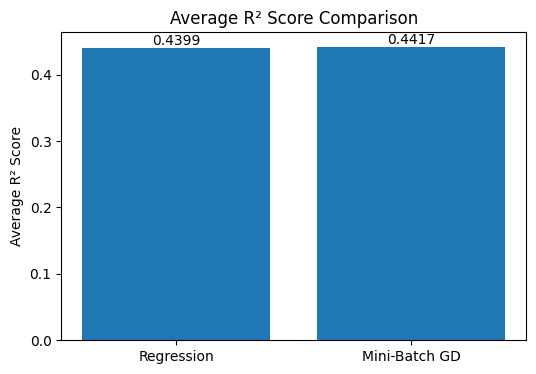

In [ ]:

plt.figure(figsize=(6, 4))
plt.bar(['Regression', 'Mini-Batch GD'], [reg_r2, mb_r2])

plt.ylabel('Average R² Score')
plt.title('Average R² Score Comparison')

# Show values on top of bars
for i, v in enumerate([reg_r2, mb_r2]):
    plt.text(i, v, f'{v:.4f}', ha='center', va='bottom')

plt.show()

In [ ]:
from sklearn.linear_model import SGDRegressor



In [ ]:
sgd = SGDRegressor(learning_rate='constant',eta0=0.1)

In [ ]:
batch_size = 30

for i in range(100):

    idx = random.sample(range(x_train.shape[0]),batch_size)
    sgd.partial_fit(x_train[idx],y_train[idx])

In [ ]:

print(sgd.coef_)
print(sgd.intercept_)

[ -21.1214113  -203.45338232  532.48931648  315.18064483  -61.43263909
 -133.99884385 -176.1768722    81.419059    523.64236919   60.04158318]
[156.586189]


In [ ]:
y_pred = sgd.predict(x_test)

In [ ]:
sk_mb = r2_score(y_test,y_pred)

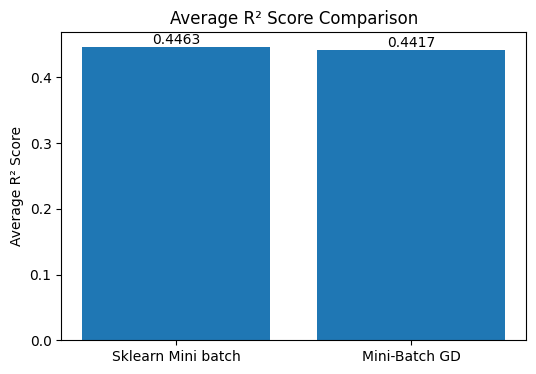

In [ ]:

plt.figure(figsize=(6, 4))
plt.bar(['Sklearn Mini batch', 'Mini-Batch GD'], [sk_mb, mb_r2])

plt.ylabel('Average R² Score')
plt.title('Average R² Score Comparison')

# Show values on top of bars
for i, v in enumerate([sk_mb, mb_r2]):
    plt.text(i, v, f'{v:.4f}', ha='center', va='bottom')

plt.show()